In [1]:
#!pip install konlpy

In [2]:
from konlpy.tag import Mecab
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding
from tensorflow.keras.utils import to_categorical

2025-05-21 16:25:35.663221: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747812335.673668    6208 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747812335.676716    6208 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747812335.685294    6208 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747812335.685315    6208 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747812335.685317    6208 computation_placer.cc:177] computation placer alr

In [3]:
train_data = pd.read_csv("./data/bank_app_reviews_train.csv")
train_data.head()

,리뷰일,평점,사용자리뷰,업체답변,은행명
0,2023-12-21,5,엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 ㅎㅎ 저도 쓰고있음!,NaN,하나
1,2025-02-17,1,Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...,안녕하세요. 신한은행입니다.\n먼저 SOL사용에 불편을 드려 죄송합니다.\n어플의 ...,신한
2,2024-07-26,5,서비스가 통합되어 있어서 점점 사용빈도가 높아지네요.,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민
3,2024-09-01,1,카드 충천이 안됌,"안녕하세요. 전민구 님, 토스팀입니다. 남겨주신 내용만으로는 겪고계신 불편사항의 자...",토스
4,2023-11-13,1,알뜰폰 인증이 안돼요.....,"안녕하세요 헤이모두들안녕님, 우리은행입니다. 먼저 이용에 불편을 드려 매우 죄송합니...",우리


* 특문제거함수

In [4]:
import re

def clean_text(text) :
    cleaned = re.sub(r'[^가-힣a-zA-Z0-9\s]','',text) #한글, 영문, 숫자만 추출
    cleaned = re.sub(r'\s+', ' ', cleaned) # 연속된 공백을 하나의 공백으로 줄이기
    return cleaned.strip()

* 사용자리뷰에서 특문 제거하기

In [5]:
train_data['사용자리뷰'] = train_data['사용자리뷰'].apply(clean_text)
train_data['사용자리뷰']

0                  엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 저도 쓰고있음
1        Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...
2                             서비스가 통합되어 있어서 점점 사용빈도가 높아지네요
3                                                카드 충천이 안됌
4                                              알뜰폰 인증이 안돼요
                               ...                        
22241                                      어플 시작오류가 가끔 나네요
22242                              업데이트 후에 계좌이체하는 게 자주 튕겨요
22243                                                  굳굳굳
22244                                  오래시간 같이한 나의은행 든든합니다
22245    라이브 광고 전보다 더 안좋네 아무리 주기 싫어도 겨우 3원줄거면서 너무 쪼잔하게 ...
Name: 사용자리뷰, Length: 22246, dtype: object

* is_good 컬럼 추가, 평점 4 이상은 긍정: 1로, 3 이하는 부정: 0

In [6]:
train_data['is_good'] = train_data['평점'].apply(lambda x: 1 if x >=4 else 0)
train_data['is_good']

0        1
1        0
2        1
3        0
4        0
        ..
22241    0
22242    0
22243    1
22244    1
22245    0
Name: is_good, Length: 22246, dtype: int64

* 토큰화

In [ ]:
# !pip install mecab-python3

In [8]:
mecab = Mecab()
mecab.morphs(train_data['사용자리뷰'][0])

['엄',
 '빠',
 '폰',
 '에',
 '설치',
 '해',
 '드렸',
 '는데',
 '두',
 '분',
 '다',
 '쓰',
 '기',
 '편하',
 '다고',
 '하',
 '시',
 '네요',
 '저',
 '도',
 '쓰',
 '고',
 '있',
 '음']

* 전체문장을 토큰화 한 후 tokenized_docs에 저장하기

In [10]:
tokenized_docs = train_data['사용자리뷰'].apply(mecab.morphs)

In [11]:
tokenized_docs[0]

['엄',
 '빠',
 '폰',
 '에',
 '설치',
 '해',
 '드렸',
 '는데',
 '두',
 '분',
 '다',
 '쓰',
 '기',
 '편하',
 '다고',
 '하',
 '시',
 '네요',
 '저',
 '도',
 '쓰',
 '고',
 '있',
 '음']

* 단어 인덱스 생성

In [13]:
token = Tokenizer(lower = False)
token.fit_on_texts(tokenized_docs)
print(len(token.word_index))

13010


* 문장 벡터화

In [14]:
x = token.texts_to_sequences(tokenized_docs)
print(x[0])

[5400, 1682, 170, 11, 159, 37, 2292, 14, 301, 184, 28, 45, 19, 106, 123, 1, 76, 15, 216, 5, 45, 2, 10, 64]


* 가장 긴 문장의 길이 구하기

In [15]:
max_length = max([len(i) for i in x]) + 1
max_length

302

* 가장 긴 길이에 맞춰서 패딩하기
* RNN의 경우 패딩을 post로 주는 것이 더 좋음, 단어가 앞, 0이 뒤에 붙음
* Transformer 계열(GPT같은)은 위치정보가 따로 있으므로 post든 pre든 차이가 없음

In [16]:
X_padded = pad_sequences(x, maxlen=max_length, padding = 'post' )
print(X_padded[0])

[5400 1682  170   11  159   37 2292   14  301  184   28   45   19  106
  123    1   76   15  216    5   45    2   10   64    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [18]:
X_padded.shape

(22246, 302)

In [19]:
y = train_data['is_good']
y.value_countsts()

is_good
1    13240
0     9006
Name: count, dtype: int64

* 홀드아웃 하기

In [20]:
#!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 91.0 MB/s eta 0:00:00
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn] [scikit-learn]


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_trian, X_valid, y_train, y_valid = train_test_split(X_padded, y, test_size=0.3, stratify=y, random_state=42)

In [23]:
# 임베딩에 입력할 단어 수 추출하기
word_size = len(token.word_index) + 1
print(word_size)

13011


# 양방향 RNN 네트워크를 이용해 텍스트 분석하기

In [36]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [33]:
birnn = Sequential()
birnn.add(Input(shape=(max_length,)))
birnn.add(Embedding(input_dim=word_size, output_dim=64))
birnn.add(Bidirectional(SimpleRNN(128, return_sequences=False, activation='tanh')))
birnn.add(Dense(32, activation='relu'))
birnn.add(Dropout(0.5))
birnn.add(Dense(1, activation='sigmoid'))
birnn.summary()

I0000 00:00:1747814560.268989    6208 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4581 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:08:00.0, compute capability: 8.6


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 302, 64)        │       832,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890,369 (3.40 MB)

 Trainable params: 890,369 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9133 - auc: 0.9559 - loss: 0.2554
Epoch 1: val_loss improved from inf to 0.27591, saving model to ./model/bank_app_review_birnn.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 12s 149ms/step - accuracy: 0.9133 - auc: 0.9559 - loss: 0.2553 - val_accuracy: 0.8915 - val_auc: 0.9510 - val_loss: 0.2759
Epoch 2/1000
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9352 - auc: 0.9725 - loss: 0.1967
Epoch 2: val_loss did not improve from 0.27591
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.9352 - auc: 0.9725 - loss: 0.1967 - val_accuracy: 0.8894 - val_auc: 0.9460 - val_loss: 0.2960
Epoch 3/1000
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9394 - auc: 0.9786 - loss: 0.1739
Epoch 3: val_loss did not improve from 0.27591
61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.9392 - auc: 0.9784 - loss: 0.1746 - val_accuracy: 0.8819 - val_auc: 0.9493 - val_loss: 0.3038
Epoch 4/1000
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - 

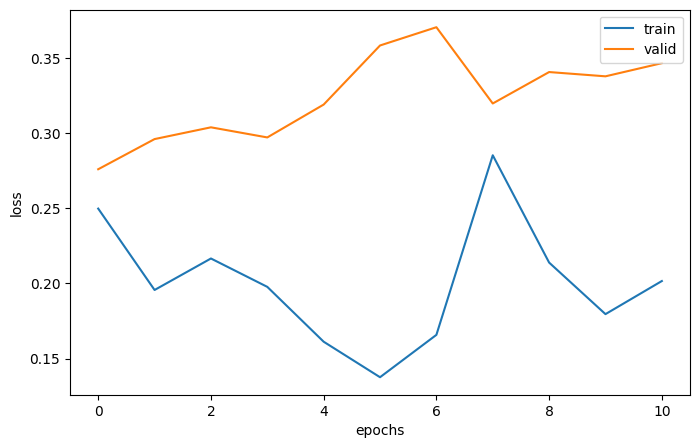

In [39]:
birnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
model_path = "./model/bank_app_review_birnn.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                            save_best_only=True,
                            verbose=1)
birnn_history = birnn.fit(X_trian, y_train, epochs=1000, batch_size=256,
                         validation_data=(X_valid, y_valid),
                         callbacks=[early_stop, checkpoint])
plt.figure(figsize=(8, 5))
plt.plot(birnn_history.history['loss'])
plt.plot(birnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

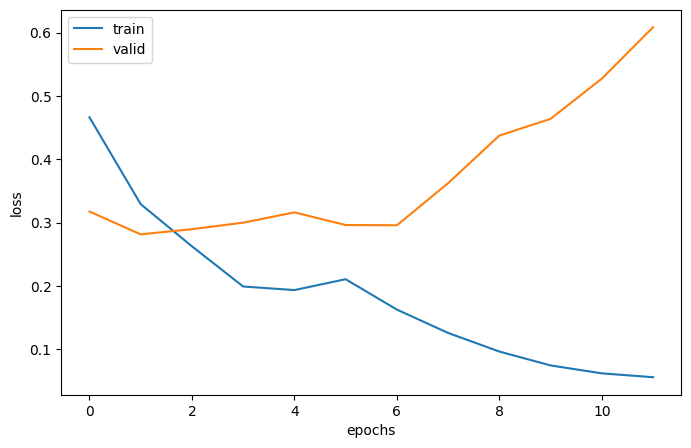

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(birnn_history.history['loss'])
plt.plot(birnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [40]:
print(birnn.evaluate(X_valid, y_valid))

209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8980 - auc: 0.9541 - loss: 0.2670
[0.27590492367744446, 0.89151930809021, 0.9510406255722046]


In [41]:
pred = birnn.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step


array([[0.9927874 ],
       [0.86177737],
       [0.05522833],
       ...,
       [0.93027264],
       [0.10861486],
       [0.925382  ]], dtype=float32)

In [42]:
pred = pd.DataFrame(pred)

In [45]:
y_valid = pd.DataFrame(y_valid.reset_index(drop=True))
y_valid

,is_good
0,1
1,1
2,0
3,1
4,0
...,...
6669,0
6670,1
6671,1
6672,0


In [ ]:
pd.DataFrame(dict(y_valid=y_valid.reset_index(drop=True), pred=pred))

In [46]:
result = pd.concat([y_valid, pred], axis = 1)
result

,is_good,0
0,1,0.992787
1,1,0.861777
2,0,0.055228
3,1,0.983916
4,0,0.070205
...,...,...
6669,0,0.046464
6670,1,0.859941
6671,1,0.930273
6672,0,0.108615


In [47]:
result.columns = ['is_good', 'pred']
result

,is_good,pred
0,1,0.992787
1,1,0.861777
2,0,0.055228
3,1,0.983916
4,0,0.070205
...,...,...
6669,0,0.046464
6670,1,0.859941
6671,1,0.930273
6672,0,0.108615


In [55]:
result['pred'] = result['pred'].apply(lambda x : 1 if x > 0.5 else 0)

In [56]:
from sklearn.metrics import classification_report
print(classification_report(result['is_good'], result['pred']))

              precision    recall  f1-score   support

           0       0.40      1.00      0.58      2702
           1       0.00      0.00      0.00      3972

    accuracy                           0.40      6674
   macro avg       0.20      0.50      0.29      6674
weighted avg       0.16      0.40      0.23      6674



/home/fintech_ubuntu/miniforge3/envs/face/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fintech_ubuntu/miniforge3/envs/face/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/fintech_ubuntu/miniforge3/envs/face/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

# LSTM 과 CNN(합성곱신경망) 조합 모델로 분석하기

In [66]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, GlobalMaxPooling1D # text는 전부 1차원이기때문다

In [68]:
lstm_cnn = Sequential()
lstm_cnn.add(Input(shape=(max_length,)))
lstm_cnn.add(Embedding(input_dim=word_size, output_dim=128))
lstm_cnn.add(Dropout(0.3))
lstm_cnn.add(Conv1D(128, 5, padding='valid', activation='relu'))
lstm_cnn.add(MaxPooling1D(pool_size=4))
lstm_cnn.add(Conv1D(128, 5, padding='valid', activation='relu'))
lstm_cnn.add(MaxPooling1D(pool_size=4))
lstm_cnn.add(Bidirectional(LSTM(256, return_sequences=True)))
lstm_cnn.add(GlobalMaxPooling1D())
lstm_cnn.add(Dense(64, activation='relu'))
lstm_cnn.add(Dropout(0.3))
lstm_cnn.add(Dense(32, activation='relu'))
lstm_cnn.add(Dense(1, activation='sigmoid'))
lstm_cnn.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 302, 128)       │     1,665,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 302, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 298, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 74, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 70, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 17, 512)        │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 512)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,652,929 (10.12 MB)

 Trainable params: 2,652,929 (10.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7339 - auc: 0.7722 - loss: 0.5356
Epoch 1: val_loss improved from inf to 0.31009, saving model to ./model/bank_app_review_lstm_cnn.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.7346 - auc: 0.7730 - loss: 0.5347 - val_accuracy: 0.8791 - val_auc: 0.9412 - val_loss: 0.3101
Epoch 2/1000
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9043 - auc: 0.9503 - loss: 0.2677
Epoch 2: val_loss improved from 0.31009 to 0.26726, saving model to ./model/bank_app_review_lstm_cnn.keras
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9043 - auc: 0.9503 - loss: 0.2677 - val_accuracy: 0.8939 - val_auc: 0.9527 - val_loss: 0.2673
Epoch 3/1000
121/122 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9357 - auc: 0.9736 - loss: 0.1896
Epoch 3: val_loss did not improve from 0.26726
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9357 - auc: 0.9736 - loss: 0.1897 - val_accuracy: 0.8903 - val_auc: 0.9501 - 

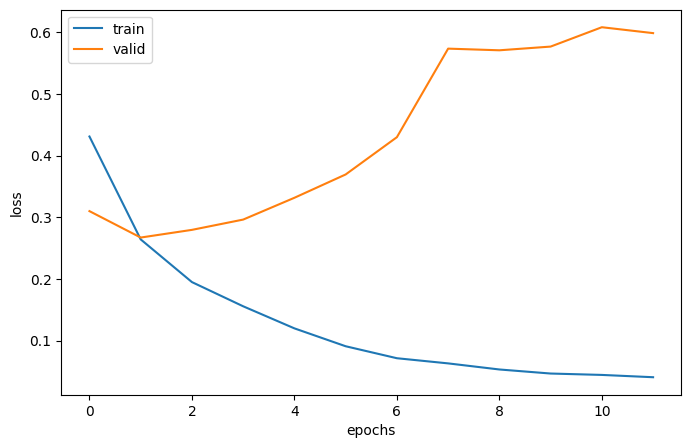

In [69]:
lstm_cnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
model_path = "./model/bank_app_review_lstm_cnn.keras"
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss',
                            save_best_only=True,
                            verbose=1)
lstm_cnn_history = lstm_cnn.fit(X_trian, y_train, epochs=1000, batch_size=128,
                         validation_data=(X_valid, y_valid),
                         callbacks=[early_stop, checkpoint])
plt.figure(figsize=(8, 5))
plt.plot(lstm_cnn_history.history['loss'])
plt.plot(lstm_cnn_history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

In [70]:
print(lstm_cnn.evaluate(X_valid, y_valid))

209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8965 - auc: 0.9540 - loss: 0.2639
[0.2672581076622009, 0.893916666507721, 0.9527266025543213]


In [72]:
pred = lstm_cnn.predict(X_valid)
pred

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


array([[0.9783376 ],
       [0.9700593 ],
       [0.06925061],
       ...,
       [0.9406432 ],
       [0.13912246],
       [0.96643096]], dtype=float32)

# Attention => GPT
* RNN이나 LSTM은 전체 문장을 기억
* 중요한 단어에만 집중

In [73]:
#!pip install attention

In [74]:
from attention import Attention

In [76]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling1D, LayerNormalization, MultiHeadAttention, AdditiveAttention

In [78]:
inputs = Input(shape=(max_length,))
x = Embedding(input_dim=word_size, output_dim=128)(inputs)
x = Dropout(0.3)(x)
# 양방향 LSTM
x = Bidirectional(LSTM(128, return_sequences=True))(x)
# 멀티헤드 어텐션
attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x,x)
attn_output = Dropout(0.3)(attn_output)
x = Add()([x, attn_output])
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)
# DNN
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)
# 출력층
outputs = Dense(1, activation='sigmoid')(x)
model = Model(inputs=inputs, outputs=outputs)
model.summary()


NameError: name 'Add' is not defined